# Compute Mean Geodesic Distances at the subject level
## based on fixed Schaefer-400 template distances
(as measure of functional connectivity profiles)

## Load Packages

In [8]:
# General
import os
import sys
import numpy as np
import pandas as pd
import csv
import math
from math import isnan
import statistics
import pickle
from collections import Counter

# Computing / Analyses
import scipy.io  # loadmat
import hdf5storage  # hdf5storage to write in HDF5 format (instead of .mat file, when matrix is too large) -> hdf5storage.write() hdf5storage.read()
import fnmatch # for comparing patterns of syntax
from scipy import stats
import sklearn 
from brainstat.stats.terms import FixedEffect
from brainstat.stats.SLM import SLM
from statsmodels.stats.multitest import fdrcorrection # does not yield exactly the same FDR correction as R but the same up to 14th decimal place so good enough
import statsmodels.regression.mixed_linear_model as sm
from sklearn.preprocessing import scale

# Visualisation
import matplotlib.pyplot as plt 
import seaborn as sns
import vtk
from IPython.display import display
import matplotlib.collections as clt
import matplotlib.colors as mcolors
from nilearn import plotting
#import ptitprince as pt  # commented out because clashing dependencies with seaborn
import cmocean

# Neuroimaging
import nibabel as nib
import nilearn
from brainstat.datasets import fetch_parcellation
from enigmatoolbox.permutation_testing import spin_test, shuf_test

# Gradients
import brainspace
from brainspace.datasets import load_parcellation, load_conte69
from brainspace.plotting import plot_hemispheres
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels

## Define directories

In [9]:
codedir = os.path.abspath('')  # obtain current direction from which script is runnning

datadir_local = '/data/p_02667/development/data/'
datadir = '/data/pt_02667/data/ABCD/'

resdir = '/data/p_02667/development/results/'
resdir_fig = '/data/p_02667/development/results/figures/'

## Import functions

In [10]:
%run p3_myfunctions.ipynb

# Data 

## Import the Yeo 7 network coding for the Schaefer 400 parcellation scheme

In [11]:
# labels: 1=visual, 2=sensory motor, 3=dorsal attention, 4=ventral attention, 5=limbic, 6=fronto parietal, 7= DMN

yeo7_networks_array = np.genfromtxt('/data/pt_02667/data/yeo_7.csv', delimiter=',', skip_header=0)

### Define custom yeo 7 colormap

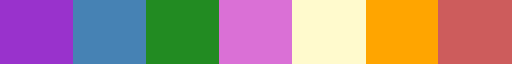

In [12]:
from matplotlib.colors import ListedColormap

# define custom colormap using color names (in order of corresponding networks: 1 visual, 2 sensorimotor, 3 dorsal attention, 4 ventral attention, 5 limbic, 6 fronto parietal, 7 DMN)
colors_yeo7 = ['darkorchid', 'steelblue', 'forestgreen', 'orchid', 'lemonchiffon', 'orange',  'indianred']

yeo7_colormap = ListedColormap(colors_yeo7, 'custom_colormap')

yeo7_colormap

In [13]:
# original Yeo network colors
palette_labeled_networks = {'DMN': 'indianred',  
                            'dorsal attention' : 'forestgreen',  
                            'fronto parietal' : 'orange',  
                            'limbic' : 'lemonchiffon',  
                            'sensory motor' : 'steelblue',
                            'ventral attention' : 'orchid', 
                            'visual' : 'darkorchid'} 

# making an array with yeo network labels (names instead of numbers)
yeo7_networks_array_labels = []

for i in yeo7_networks_array:
    if i == 1:
        yeo7_networks_array_labels.append('visual')
    elif i == 2:
        yeo7_networks_array_labels.append('sensory motor')
    elif i == 3:
        yeo7_networks_array_labels.append('dorsal attention')
    elif i == 4:
        yeo7_networks_array_labels.append('ventral attention')
    elif i == 5:
        yeo7_networks_array_labels.append('limbic')
    elif i == 6:
        yeo7_networks_array_labels.append('fronto parietal')
    elif i == 7:
        yeo7_networks_array_labels.append('DMN')

yeo7_networks_array_labels = np.asarray(yeo7_networks_array_labels)

network_names = ["visual", "sensory motor", "dorsal attention", "ventral attention", "limbic", "fronto parietal", "DMN"]

print("Number of parcels in each Yeo network:")
for i in range(len(network_names)):
    print(f"- {network_names[i]}: {yeo7_networks_array_labels.tolist().count(network_names[i])}")

Number of parcels in each Yeo network:
- visual: 61
- sensory motor: 77
- dorsal attention: 46
- ventral attention: 47
- limbic: 26
- fronto parietal: 53
- DMN: 90


## Cleaned FC matrices

From p3_cleaning_final_sample.py

### Baseline

In [14]:
## This is current largest sample

# Loading HDF file (file was too large for matfile), with HDF reader e.g., hdf5storage
hdf_file_fc_matrices_baseline_clean = hdf5storage.read(filename=datadir_local+'abcd_fc_matrices_baseline_clean.h5')
hdf_file_fc_matrices_baseline_clean.keys()

dict_keys(['fc_matrices_baseline', 'fc_matrices_baseline_z', 'sub_ID_baseline'])

In [15]:
fc_matrices_baseline = hdf_file_fc_matrices_baseline_clean['fc_matrices_baseline_z']   # take r-to-z transformed matrices
sub_ID_baseline = hdf_file_fc_matrices_baseline_clean['sub_ID_baseline']

fc_matrices_baseline.shape

(4064, 400, 400)

### 2y follow-up

In [16]:
## This is current largest sample

# Loading HDF file (file was too large for matfile), with HDF reader e.g., hdf5storage
hdf_file_fc_matrices_fu2y_clean = hdf5storage.read(filename=datadir_local+'abcd_fc_matrices_fu2y_clean.h5')
hdf_file_fc_matrices_fu2y_clean.keys()

dict_keys(['fc_matrices_fu2y', 'fc_matrices_fu2y_z', 'sub_ID_fu2y'])

In [17]:
fc_matrices_fu2y = hdf_file_fc_matrices_fu2y_clean['fc_matrices_fu2y_z']  # take r-to-z transformed matrices
sub_ID_fu2y = hdf_file_fc_matrices_fu2y_clean['sub_ID_fu2y']

fc_matrices_fu2y.shape

(1296, 400, 400)

### 4y follow-up

In [18]:
## This is current largest sample

# Loading HDF file (file was too large for matfile), with HDF reader e.g., hdf5storage
hdf_file_fc_matrices_fu4y_clean = hdf5storage.read(filename=datadir_local+'abcd_fc_matrices_fu4y_clean.h5')
hdf_file_fc_matrices_fu4y_clean.keys()

dict_keys(['fc_matrices_fu4y', 'fc_matrices_fu4y_z', 'sub_ID_fu4y'])

In [19]:
fc_matrices_fu4y = hdf_file_fc_matrices_fu4y_clean['fc_matrices_fu4y_z']  # take r-to-z transformed matrices
sub_ID_fu4y = hdf_file_fc_matrices_fu4y_clean['sub_ID_fu4y']

fc_matrices_fu4y.shape

(963, 400, 400)

## Template Schaefer 400 geodesic distances

(400, 400)


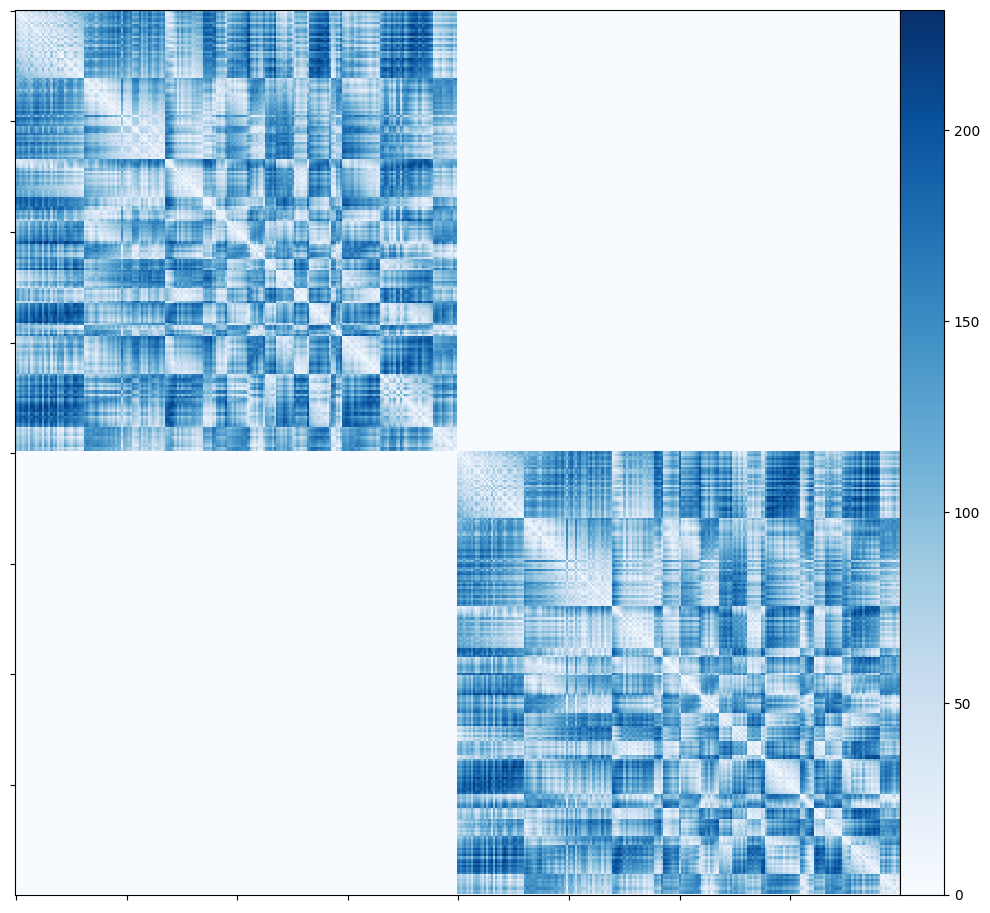

In [20]:
# Set the path to the the geodesic distance connectome
cnt_gd = "/data/pt_02667/data/ABCD/micapipe_geodesic_distances/template_GD/template_atlas-schaefer-400_GD.shape.gii"

# Load the cortical connectome
mtx_gd = nib.load(cnt_gd).darrays[0].data

# Indices to remove: medial wall
medial_wall_indices = [0, 201]

template_gd_schaefer400 = np.delete(mtx_gd, medial_wall_indices, axis=0)  # rm rows
template_gd_schaefer400 = np.delete(template_gd_schaefer400, medial_wall_indices, axis=1)  # rm columns

print(template_gd_schaefer400.shape)  # Should be (400, 400)

# Plot the matrix
corr_plot = plotting.plot_matrix(template_gd_schaefer400, figure=(10, 10), labels=None, cmap='Blues')

## Fetch fsaverage parcellation (20484 vertices) coded for Schaefer 400 parcels 
**NOTE: schaefer_400_fs5 == 0 corresponds to midline (labels go from 0-400) -> disregard 0 in calculations and plotting**

In [21]:
# fetch the fsaverage parcellation labeling each of fsaverage5's 20484 vertices with its corresponding Schaefer parcel
schaefer_400_fs5 = fetch_parcellation("fsaverage5", "schaefer", 400)

In [22]:
schaefer_400_fs5.shape

(20484,)

## HCP adult gradients (G1 / S-A axis) + sex effects

### Margulies gradient G1

In [23]:
Margulies_gradients_fsa5 = []
Margulies_gradients_schaefer400 = []

# Margulies published first 5 gradients
for i in range(1,6):

    # load left and right hemispheres (.agg_data() makes the Gifti format accessible) -> shape per hemi is 10242
    Margulies_fsa5_grad_L = nib.load('/data/p_02667/development/data/Gradients_Margulies2016/Gradients_Margulies2016/fsaverage/hcp.embed.grad_'+str(i)+'.L.fsa5.func.gii').agg_data()
    Margulies_fsa5_grad_R = nib.load('/data/p_02667/development/data/Gradients_Margulies2016/Gradients_Margulies2016/fsaverage/hcp.embed.grad_'+str(i)+'.R.fsa5.func.gii').agg_data()


    # concatenate left and right hemispheres - this data is shaped (20484), corresponding to vertices (including medial wall)
    Margulies_fsa5_grad_wholebrain = np.concatenate((Margulies_fsa5_grad_L, Margulies_fsa5_grad_R), axis=0)

    # append to list
    Margulies_gradients_fsa5.append(Margulies_fsa5_grad_wholebrain)

    # transform to Schaefer parcellation and append to list
    Margulies_gradients_schaefer400.append(fs5_to_schaefer400(Margulies_fsa5_grad_wholebrain, seven_networks=True))


Margulies_gradients_fsa5 = np.array(Margulies_gradients_fsa5)
Margulies_gradients_schaefer400 = np.array(Margulies_gradients_schaefer400)

In [24]:
# adult template: Margulies_gradients_schaefer400[0]
Margulies_gradients_schaefer400.shape

(5, 400)

# Compute mean geodesic distance per subject

## Baseline

In [25]:
### arrays that will contain the mean geodesic distances for 10% connections at the individual level

# array will contain the mean geodesic distances (from the template GD Schaefer 400 matrix) of a subject´s top 10% connections by seed region at the individual level (N x 400)
mean_gd_top10_baseline = []


# iterate over subjects
for i in range(len(fc_matrices_baseline)):
    print(f"----- subject = {i+1} ----")

    # temporary list for each subject's mean gd of their top10% connections
    sub_mean_gd_top10 = []


    # iterate over each row of the subject's fc 400x400 matrix 
    for j in range(len(fc_matrices_baseline[0])):

        # identify the indices of the top 10% functional connections i.e., top 20 connections (10% of 200 (400/2) given that geodesic distance was calculated across single hemispheres only)
        # code explanation available at: https://www.educative.io/answers/how-to-get-indices-of-n-maximum-values-in-numpy-arrays
        # retrieving indices from subject i and row j of the fc matrix
        
        # if left hemisphere
        if j <= 199:
            # take top functional connections from left hemisphere
            indices_top_fc = np.argsort(fc_matrices_baseline[i][j][:200])[::-1][:20]          
               
        else:
            # take top functional connections from right hemisphere (need to add 200 to the indices outputted given that we are taking them from 200-parcel right hemisphere but applying them to 400 array in geodesic_distances_matrices_corrected)
            indices_top_fc = 200 + np.argsort(fc_matrices_baseline[i][j][200:])[::-1][:20]


        # take the mean GD (from the template GD Schaefer 400 matrix) of top 10% connections indices for that given subject
        mean_gd_top10_temp = np.mean(template_gd_schaefer400[j][indices_top_fc], axis=0)

        # append temporary mean GD of 10% connections of subject's row
        sub_mean_gd_top10.append(mean_gd_top10_temp)  
     
    # append current subject's list of mean GD of top 10% connections per row to full subject list
    mean_gd_top10_baseline.append(sub_mean_gd_top10)

            
mean_gd_top10_baseline = np.array(mean_gd_top10_baseline)

----- subject = 1 ----
----- subject = 2 ----
----- subject = 3 ----
----- subject = 4 ----
----- subject = 5 ----
----- subject = 6 ----
----- subject = 7 ----
----- subject = 8 ----
----- subject = 9 ----
----- subject = 10 ----
----- subject = 11 ----
----- subject = 12 ----
----- subject = 13 ----
----- subject = 14 ----
----- subject = 15 ----
----- subject = 16 ----
----- subject = 17 ----
----- subject = 18 ----
----- subject = 19 ----
----- subject = 20 ----
----- subject = 21 ----
----- subject = 22 ----
----- subject = 23 ----
----- subject = 24 ----
----- subject = 25 ----
----- subject = 26 ----
----- subject = 27 ----
----- subject = 28 ----
----- subject = 29 ----
----- subject = 30 ----
----- subject = 31 ----
----- subject = 32 ----
----- subject = 33 ----
----- subject = 34 ----
----- subject = 35 ----
----- subject = 36 ----
----- subject = 37 ----
----- subject = 38 ----
----- subject = 39 ----
----- subject = 40 ----
----- subject = 41 ----
----- subject = 42 ----
-

In [26]:
mean_gd_top10_baseline.shape

(4064, 400)

In [27]:
# compute for each yeo network (at the individual level): mean GD od the given network

# mean geodesic distances (from the template GD Schaefer 400 matrix) of top 10% connections by seed region at the individual level
mean_gd_top10 = mean_gd_top10_baseline.T  # transpose to obtain shape (400 x N) in order to access/index the relevant network nodes

yeo_mean_gd_baseline = []  # mean GD of top 10% functional connections for given network (7 x N)

# iterate over the 7 Yeo networks
for n in range(7):
    
    # identify the nodes of given Yeo network
    netNodes = np.where(yeo7_networks_array == (n + 1))
    netNodes = np.squeeze(netNodes)
    
    # get the GD values of the nodes of the given Yeo network, for each subject (shape: number of nodes in network x N)
    gd_net = mean_gd_top10[netNodes]
    
    # mean GD of the given Yeo network for each subject (shape: N)
    yeo_mean_gd_net = np.mean(gd_net, axis=0)  
    yeo_mean_gd_baseline.append(yeo_mean_gd_net)
    
yeo_mean_gd_baseline = np.array(yeo_mean_gd_baseline)  # shape: 7 x N


In [28]:
yeo_mean_gd_baseline.shape

(7, 4064)

In [29]:
# ordered yeo_labels = ["V", "SM", "DA", "VA", "L", "FP", "DMN"]

V_mean_gd_baseline = yeo_mean_gd_baseline[0]
SM_mean_gd_baseline = yeo_mean_gd_baseline[1]
DA_mean_gd_baseline = yeo_mean_gd_baseline[2]
VA_mean_gd_baseline = yeo_mean_gd_baseline[3]
L_mean_gd_baseline = yeo_mean_gd_baseline[4]
FP_mean_gd_baseline = yeo_mean_gd_baseline[5]
DMN_mean_gd_baseline = yeo_mean_gd_baseline[6]

In [30]:
# export
mdict = {'mean_gd_top10_baseline': mean_gd_top10_baseline, 'yeo_mean_gd_baseline': yeo_mean_gd_baseline, 
         'V_mean_gd_baseline': V_mean_gd_baseline, 'SM_mean_gd_baseline': SM_mean_gd_baseline, 'DA_mean_gd_baseline': DA_mean_gd_baseline, 
         'VA_mean_gd_baseline': VA_mean_gd_baseline, 'L_mean_gd_baseline': L_mean_gd_baseline, 'FP_mean_gd_baseline': FP_mean_gd_baseline, 
         'DMN_mean_gd_baseline': DMN_mean_gd_baseline,
         'sub_ID_baseline': sub_ID_baseline}

scipy.io.savemat(datadir_local+'geodesic_distances_ref_template_baseline.mat', mdict)

## fu2y

In [31]:
### arrays that will contain the mean geodesic distances for 10% connections at the individual level

# array will contain the mean geodesic distances (from the template GD Schaefer 400 matrix) of a subject´s top 10% connections by seed region at the individual level (N x 400)
mean_gd_top10_fu2y = []


# iterate over subjects
for i in range(len(fc_matrices_fu2y)):
    print(f"----- subject = {i+1} ----")

    # temporary list for each subject's mean gd of their top10% connections
    sub_mean_gd_top10 = []


    # iterate over each row of the subject's fc 400x400 matrix 
    for j in range(len(fc_matrices_fu2y[0])):

        # identify the indices of the top 10% functional connections i.e., top 20 connections (10% of 200 (400/2) given that geodesic distance was calculated across single hemispheres only)
        # code explanation available at: https://www.educative.io/answers/how-to-get-indices-of-n-maximum-values-in-numpy-arrays
        # retrieving indices from subject i and row j of the fc matrix
        
        # if left hemisphere
        if j <= 199:
            # take top functional connections from left hemisphere
            indices_top_fc = np.argsort(fc_matrices_fu2y[i][j][:200])[::-1][:20]          
               
        else:
            # take top functional connections from right hemisphere (need to add 200 to the indices outputted given that we are taking them from 200-parcel right hemisphere but applying them to 400 array in geodesic_distances_matrices_corrected)
            indices_top_fc = 200 + np.argsort(fc_matrices_fu2y[i][j][200:])[::-1][:20]


        # take the mean GD (from the template GD Schaefer 400 matrix) of top 10% connections indices for that given subject
        mean_gd_top10_temp = np.mean(template_gd_schaefer400[j][indices_top_fc], axis=0)

        # append temporary mean GD of 10% connections of subject's row
        sub_mean_gd_top10.append(mean_gd_top10_temp)  
     
    # append current subject's list of mean GD of top 10% connections per row to full subject list
    mean_gd_top10_fu2y.append(sub_mean_gd_top10)

            
mean_gd_top10_fu2y = np.array(mean_gd_top10_fu2y)

----- subject = 1 ----
----- subject = 2 ----
----- subject = 3 ----
----- subject = 4 ----
----- subject = 5 ----
----- subject = 6 ----
----- subject = 7 ----
----- subject = 8 ----
----- subject = 9 ----
----- subject = 10 ----
----- subject = 11 ----
----- subject = 12 ----
----- subject = 13 ----
----- subject = 14 ----
----- subject = 15 ----
----- subject = 16 ----
----- subject = 17 ----
----- subject = 18 ----
----- subject = 19 ----
----- subject = 20 ----
----- subject = 21 ----
----- subject = 22 ----
----- subject = 23 ----
----- subject = 24 ----
----- subject = 25 ----
----- subject = 26 ----
----- subject = 27 ----
----- subject = 28 ----
----- subject = 29 ----
----- subject = 30 ----
----- subject = 31 ----
----- subject = 32 ----
----- subject = 33 ----
----- subject = 34 ----
----- subject = 35 ----
----- subject = 36 ----
----- subject = 37 ----
----- subject = 38 ----
----- subject = 39 ----
----- subject = 40 ----
----- subject = 41 ----
----- subject = 42 ----
-

In [32]:
mean_gd_top10_fu2y.shape

(1296, 400)

In [33]:
# compute for each yeo network (at the individual level): mean GD od the given network

# mean geodesic distances (from the template GD Schaefer 400 matrix) of top 10% connections by seed region at the individual level
mean_gd_top10 = mean_gd_top10_fu2y.T  # transpose to obtain shape (400 x N) in order to access/index the relevant network nodes

yeo_mean_gd_fu2y = []  # mean GD of top 10% functional connections for given network (7 x N)

# iterate over the 7 Yeo networks
for n in range(7):
    
    # identify the nodes of given Yeo network
    netNodes = np.where(yeo7_networks_array == (n + 1))
    netNodes = np.squeeze(netNodes)
    
    # get the GD values of the nodes of the given Yeo network, for each subject (shape: number of nodes in network x N)
    gd_net = mean_gd_top10[netNodes]
    
    # mean GD of the given Yeo network for each subject (shape: N)
    yeo_mean_gd_net = np.mean(gd_net, axis=0)  
    yeo_mean_gd_fu2y.append(yeo_mean_gd_net)
    
yeo_mean_gd_fu2y = np.array(yeo_mean_gd_fu2y)  # shape: 7 x N


In [34]:
yeo_mean_gd_fu2y.shape

(7, 1296)

In [35]:
# ordered yeo_labels = ["V", "SM", "DA", "VA", "L", "FP", "DMN"]

V_mean_gd_fu2y = yeo_mean_gd_fu2y[0]
SM_mean_gd_fu2y = yeo_mean_gd_fu2y[1]
DA_mean_gd_fu2y = yeo_mean_gd_fu2y[2]
VA_mean_gd_fu2y = yeo_mean_gd_fu2y[3]
L_mean_gd_fu2y = yeo_mean_gd_fu2y[4]
FP_mean_gd_fu2y = yeo_mean_gd_fu2y[5]
DMN_mean_gd_fu2y = yeo_mean_gd_fu2y[6]

In [36]:
# export
mdict = {'mean_gd_top10_fu2y': mean_gd_top10_fu2y, 'yeo_mean_gd_fu2y': yeo_mean_gd_fu2y, 
         'V_mean_gd_fu2y': V_mean_gd_fu2y, 'SM_mean_gd_fu2y': SM_mean_gd_fu2y, 'DA_mean_gd_fu2y': DA_mean_gd_fu2y, 
         'VA_mean_gd_fu2y': VA_mean_gd_fu2y, 'L_mean_gd_fu2y': L_mean_gd_fu2y, 'FP_mean_gd_fu2y': FP_mean_gd_fu2y, 
         'DMN_mean_gd_fu2y': DMN_mean_gd_fu2y,
         'sub_ID_fu2y': sub_ID_fu2y}

scipy.io.savemat(datadir_local+'geodesic_distances_ref_template_fu2y.mat', mdict)

## fu4y

In [37]:
### arrays that will contain the mean geodesic distances for 10% connections at the individual level

# array will contain the mean geodesic distances (from the template GD Schaefer 400 matrix) of a subject´s top 10% connections by seed region at the individual level (N x 400)
mean_gd_top10_fu4y = []


# iterate over subjects
for i in range(len(fc_matrices_fu4y)):
    print(f"----- subject = {i+1} ----")

    # temporary list for each subject's mean gd of their top10% connections
    sub_mean_gd_top10 = []


    # iterate over each row of the subject's fc 400x400 matrix 
    for j in range(len(fc_matrices_fu4y[0])):

        # identify the indices of the top 10% functional connections i.e., top 20 connections (10% of 200 (400/2) given that geodesic distance was calculated across single hemispheres only)
        # code explanation available at: https://www.educative.io/answers/how-to-get-indices-of-n-maximum-values-in-numpy-arrays
        # retrieving indices from subject i and row j of the fc matrix
        
        # if left hemisphere
        if j <= 199:
            # take top functional connections from left hemisphere
            indices_top_fc = np.argsort(fc_matrices_fu4y[i][j][:200])[::-1][:20]          
               
        else:
            # take top functional connections from right hemisphere (need to add 200 to the indices outputted given that we are taking them from 200-parcel right hemisphere but applying them to 400 array in geodesic_distances_matrices_corrected)
            indices_top_fc = 200 + np.argsort(fc_matrices_fu4y[i][j][200:])[::-1][:20]


        # take the mean GD (from the template GD Schaefer 400 matrix) of top 10% connections indices for that given subject
        mean_gd_top10_temp = np.mean(template_gd_schaefer400[j][indices_top_fc], axis=0)

        # append temporary mean GD of 10% connections of subject's row
        sub_mean_gd_top10.append(mean_gd_top10_temp)  
     
    # append current subject's list of mean GD of top 10% connections per row to full subject list
    mean_gd_top10_fu4y.append(sub_mean_gd_top10)

            
mean_gd_top10_fu4y = np.array(mean_gd_top10_fu4y)

----- subject = 1 ----
----- subject = 2 ----
----- subject = 3 ----
----- subject = 4 ----
----- subject = 5 ----
----- subject = 6 ----
----- subject = 7 ----
----- subject = 8 ----
----- subject = 9 ----
----- subject = 10 ----
----- subject = 11 ----
----- subject = 12 ----
----- subject = 13 ----
----- subject = 14 ----
----- subject = 15 ----
----- subject = 16 ----
----- subject = 17 ----
----- subject = 18 ----
----- subject = 19 ----
----- subject = 20 ----
----- subject = 21 ----
----- subject = 22 ----
----- subject = 23 ----
----- subject = 24 ----
----- subject = 25 ----
----- subject = 26 ----
----- subject = 27 ----
----- subject = 28 ----
----- subject = 29 ----
----- subject = 30 ----
----- subject = 31 ----
----- subject = 32 ----
----- subject = 33 ----
----- subject = 34 ----
----- subject = 35 ----
----- subject = 36 ----
----- subject = 37 ----
----- subject = 38 ----
----- subject = 39 ----
----- subject = 40 ----
----- subject = 41 ----
----- subject = 42 ----
-

In [38]:
mean_gd_top10_fu4y.shape

(963, 400)

In [39]:
# compute for each yeo network (at the individual level): mean GD od the given network

# mean geodesic distances (from the template GD Schaefer 400 matrix) of top 10% connections by seed region at the individual level
mean_gd_top10 = mean_gd_top10_fu4y.T  # transpose to obtain shape (400 x N) in order to access/index the relevant network nodes

yeo_mean_gd_fu4y = []  # mean GD of top 10% functional connections for given network (7 x N)

# iterate over the 7 Yeo networks
for n in range(7):
    
    # identify the nodes of given Yeo network
    netNodes = np.where(yeo7_networks_array == (n + 1))
    netNodes = np.squeeze(netNodes)
    
    # get the GD values of the nodes of the given Yeo network, for each subject (shape: number of nodes in network x N)
    gd_net = mean_gd_top10[netNodes]
    
    # mean GD of the given Yeo network for each subject (shape: N)
    yeo_mean_gd_net = np.mean(gd_net, axis=0)  
    yeo_mean_gd_fu4y.append(yeo_mean_gd_net)
    
yeo_mean_gd_fu4y = np.array(yeo_mean_gd_fu4y)  # shape: 7 x N


In [40]:
yeo_mean_gd_fu4y.shape

(7, 963)

In [41]:
# ordered yeo_labels = ["V", "SM", "DA", "VA", "L", "FP", "DMN"]

V_mean_gd_fu4y = yeo_mean_gd_fu4y[0]
SM_mean_gd_fu4y = yeo_mean_gd_fu4y[1]
DA_mean_gd_fu4y = yeo_mean_gd_fu4y[2]
VA_mean_gd_fu4y = yeo_mean_gd_fu4y[3]
L_mean_gd_fu4y = yeo_mean_gd_fu4y[4]
FP_mean_gd_fu4y = yeo_mean_gd_fu4y[5]
DMN_mean_gd_fu4y = yeo_mean_gd_fu4y[6]

In [42]:
# export
mdict = {'mean_gd_top10_fu4y': mean_gd_top10_fu4y, 'yeo_mean_gd_fu4y': yeo_mean_gd_fu4y, 
         'V_mean_gd_fu4y': V_mean_gd_fu4y, 'SM_mean_gd_fu4y': SM_mean_gd_fu4y, 'DA_mean_gd_fu4y': DA_mean_gd_fu4y, 
         'VA_mean_gd_fu4y': VA_mean_gd_fu4y, 'L_mean_gd_fu4y': L_mean_gd_fu4y, 'FP_mean_gd_fu4y': FP_mean_gd_fu4y, 
         'DMN_mean_gd_fu4y': DMN_mean_gd_fu4y,
         'sub_ID_fu4y': sub_ID_fu4y}

scipy.io.savemat(datadir_local+'geodesic_distances_ref_template_fu4y.mat', mdict)

# Plotting 
## **DO NOT USE THESE FOR FIGURE - use the "rm_outliers" versions plotted in p3_network_dispersion.ipynb where I identified outliers in S-A axis expansion metric)**

In [139]:
# computing mean at the group level per seed regions for plotting

mean_gd_top10_baseline_group = np.mean(mean_gd_top10_baseline, axis=0)
mean_gd_top10_fu2y_group = np.mean(mean_gd_top10_fu2y, axis=0)
mean_gd_top10_fu4y_group = np.mean(mean_gd_top10_fu4y, axis=0)

mean_gd_top10_all_group = np.mean(np.concatenate((mean_gd_top10_baseline, mean_gd_top10_fu2y, mean_gd_top10_fu4y), axis=0), axis=0)

## Defining min and max GD values across all (for common colorbar)

In [140]:
list_mean_gd = [mean_gd_top10_baseline_group, mean_gd_top10_fu2y_group, mean_gd_top10_fu4y_group]

min_gd_across_all = np.mean(mean_gd_top10_baseline_group)  # just taking mean as starting point, knowing there will be a lower value than that
max_gd_across_all = np.mean(mean_gd_top10_baseline_group)  # just taking mean as starting point, knowing there will be a higher value than that


for mean_gd_val in list_mean_gd:

    # checking min and max
    if min(mean_gd_val) < min_gd_across_all:
        min_gd_across_all = min(mean_gd_val)
    if max(mean_gd_val) > max_gd_across_all:
        max_gd_across_all = max(mean_gd_val)    

    print(f"Min: {min(mean_gd_val)} ; Max: {max(mean_gd_val)}")

Min: 46.532981872558594 ; Max: 126.3615493774414
Min: 46.92221450805664 ; Max: 125.4491958618164
Min: 46.70946502685547 ; Max: 126.02603149414062


## Mean geodesic distances (per seed region) - across subjects

### baseline

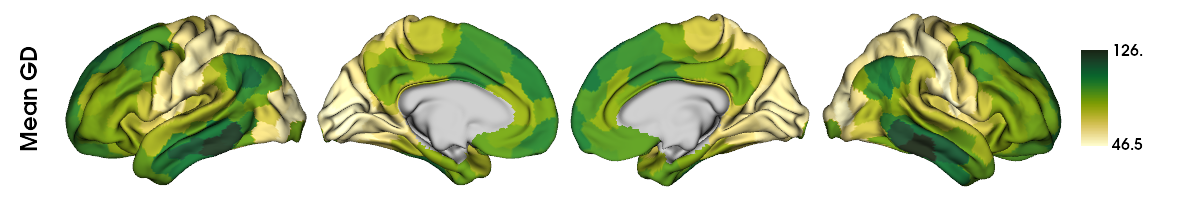

In [141]:
# defining labeling scheme and mask
labeling = load_parcellation('schaefer', scale=400, join=True)
surf_lh, surf_rh = load_conte69()
mask = labeling != 0

# map the gradient to the parcels
grad = map_to_labels(mean_gd_top10_baseline_group, labeling, mask=mask, fill=np.nan)

plot = plot_hemispheres(surf_lh, 
                        surf_rh, 
                        array_name=grad, 
                        embed_nb = True, 
                        size=(1200, 200),
                        cmap='cmo.speed', 
                        nan_color = (0.7, 0.7, 0.7, 1),
                        color_bar=True, 
                        color_range = (min_gd_across_all, max_gd_across_all),
                        label_text=['Mean GD'], 
                        zoom=1.55,
                        screenshot = False,
                        filename = resdir_fig+'plotted_hemispheres_baseline_mean_G1.svg')

display(plot)

### fu2y

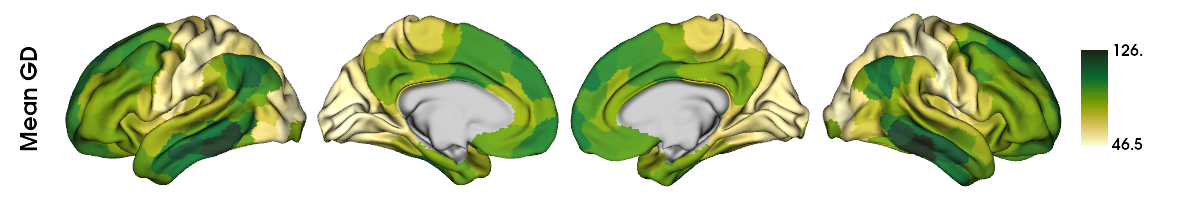

In [142]:
# defining labeling scheme and mask
labeling = load_parcellation('schaefer', scale=400, join=True)
surf_lh, surf_rh = load_conte69()
mask = labeling != 0

# map the gradient to the parcels
grad = map_to_labels(mean_gd_top10_fu2y_group, labeling, mask=mask, fill=np.nan)

plot = plot_hemispheres(surf_lh, 
                        surf_rh, 
                        array_name=grad, 
                        embed_nb = True, 
                        size=(1200, 200),
                        cmap='cmo.speed', 
                        nan_color = (0.7, 0.7, 0.7, 1),
                        color_bar=True, 
                        color_range = (min_gd_across_all, max_gd_across_all),
                        label_text=['Mean GD'], 
                        zoom=1.55,
                        screenshot = False,
                        filename = resdir_fig+'plotted_hemispheres_fu2y_mean_G2.svg')

display(plot)

### fu4y

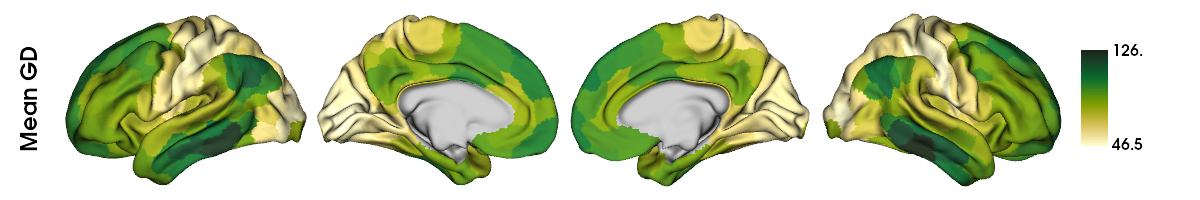

In [143]:
# defining labeling scheme and mask
labeling = load_parcellation('schaefer', scale=400, join=True)
surf_lh, surf_rh = load_conte69()
mask = labeling != 0

# map the gradient to the parcels
grad = map_to_labels(mean_gd_top10_fu4y_group, labeling, mask=mask, fill=np.nan)

plot = plot_hemispheres(surf_lh, 
                        surf_rh, 
                        array_name=grad, 
                        embed_nb = True, 
                        size=(1200, 200),
                        cmap='cmo.speed', 
                        nan_color = (0.7, 0.7, 0.7, 1),
                        color_bar=True, 
                        color_range = (min_gd_across_all, max_gd_across_all),
                        label_text=['Mean GD'], 
                        zoom=1.55,
                        screenshot = False,
                        filename = resdir_fig+'plotted_hemispheres_fu4y_mean_G2.svg')

display(plot)

### Mean across timepoints (full sample)

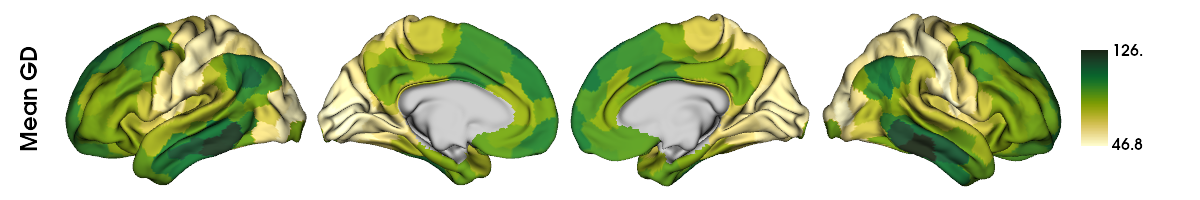

In [144]:
# defining labeling scheme and mask
labeling = load_parcellation('schaefer', scale=400, join=True)
surf_lh, surf_rh = load_conte69()
mask = labeling != 0

# map the gradient to the parcels
grad = map_to_labels(mean_gd_top10_all_group, labeling, mask=mask, fill=np.nan)

plot = plot_hemispheres(surf_lh, 
                        surf_rh, 
                        array_name=grad, 
                        embed_nb = True, 
                        size=(1200, 200),
                        cmap='cmo.speed', 
                        nan_color = (0.7, 0.7, 0.7, 1),
                        color_bar=True,
                        label_text=['Mean GD'], 
                        zoom=1.55,
                        screenshot = False,
                        filename = resdir_fig+'plotted_hemispheres_mean_GD_full_sample.svg')

display(plot)

### Plotted as a function of S-A axis loadings on adult template (per timepoint, and across timepoints)

#### Mean across all timepoints

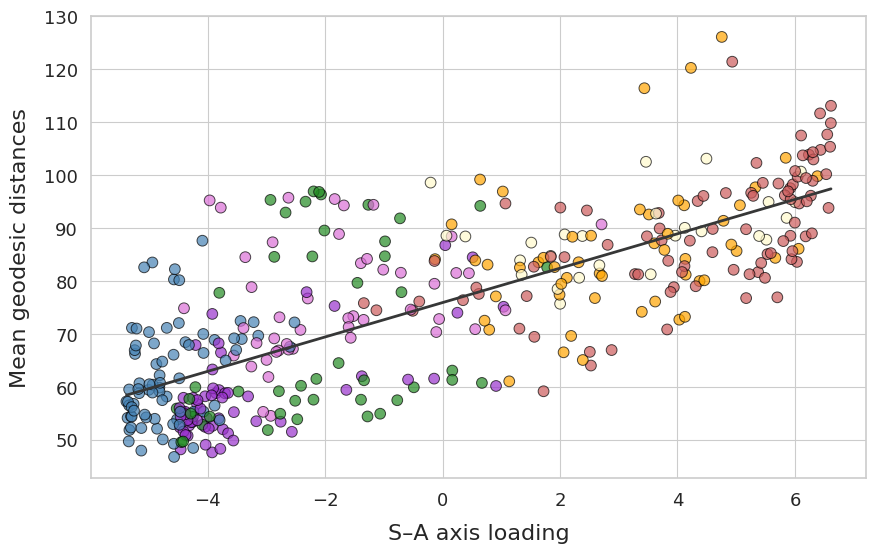

In [145]:
# make a dataframe containing the mpc and fc data (to make it plottable)
df_plot = pd.DataFrame({'SA_axis':  Margulies_gradients_schaefer400[0], 'Mean_GD': mean_gd_top10_all_group})


# --- Plot setup ---
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["grid.linestyle"] = "-"
plt.rcParams["grid.linewidth"] = 0.8

fig, ax = plt.subplots(figsize=(10, 6))

# --- Scatterplot of all parcels (color-coded by Yeo7 network) ---
sns.scatterplot(
    data=df_plot,
    x="SA_axis", y="Mean_GD",
    hue=yeo7_networks_array_labels,
    palette=palette_labeled_networks,
    s=60, edgecolor="black", linewidth=0.7,
    ax=ax,
    alpha=0.7
)

# --- Single regression line ---
sns.regplot(
    data=df_plot,
    x="SA_axis", y="Mean_GD",
    scatter=False,
    ci=None,
    line_kws={
        "color": "xkcd:dark grey",
        "lw": 2
    },
    ax=ax
)

# --- 7. Aesthetics ---
ax.set_xlabel("S–A axis loading", fontsize=16, labelpad=10)
ax.set_ylabel("Mean geodesic distances", fontsize=16, labelpad=10)
ax.tick_params(labelsize=13)
#ax.set_title(f"Mean geodesic distance along S–A axis ({timepoint_to_plot})", fontsize=18, pad=15)
#sns.despine(ax=ax)


# --- 8. Legend (networks only) ---
#handles, labels = ax.get_legend_handles_labels()
ax.legend().remove()

# save figure in directory 
plt.savefig(resdir_fig+'scatter_mean_GD_by_SAaxis.svg', dpi=300, bbox_inches="tight")  # bbox_inches is so that the figure doesn't get cut off when saving

#### By timepoint (in different alpha)

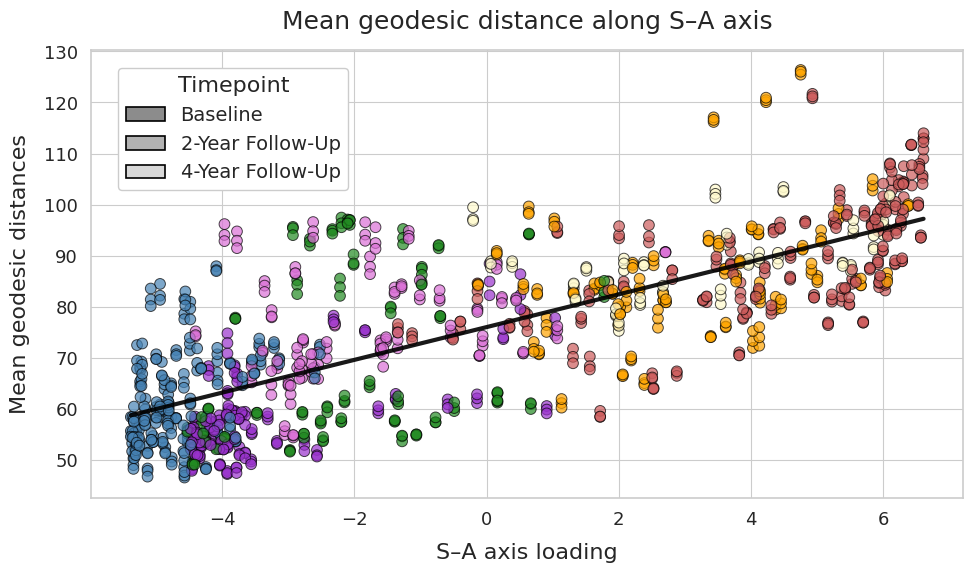

In [146]:
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# --- 1. Define your palettes (as in your barplot style) ---
palette_labeled_networks = {
    'visual': 'darkorchid',
    'sensory motor': 'steelblue',
    'dorsal attention': 'forestgreen',
    'ventral attention': 'orchid',
    'limbic': 'lemonchiffon',
    'fronto parietal': 'orange',
    'DMN': 'indianred'
}

# alpha per timepoint
alpha_map = {"Baseline": 0.9, "2-Year Follow-Up": 0.6, "4-Year Follow-Up": 0.3}
timepoints = ["Baseline", "2-Year Follow-Up", "4-Year Follow-Up"]


# --- 2. Construct dataframe ---
df_plot = pd.DataFrame({
    "S_A_axis": Margulies_gradients_schaefer400[0],
    "Yeo7": yeo7_networks_array_labels,
    "Baseline": mean_gd_top10_baseline_group,
    "Follow-up 2y": mean_gd_top10_fu2y_group,
    "Follow-up 4y": mean_gd_top10_fu4y_group
})

# Convert to long format for easier plotting
df_long = df_plot.melt(
    id_vars=["S_A_axis", "Yeo7"],
    value_vars=["Baseline", "Follow-up 2y", "Follow-up 4y"],
    var_name="Timepoint",
    value_name="Mean_GD"
)

# --- 3. Plot setup ---
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["grid.linestyle"] = "-"
plt.rcParams["grid.linewidth"] = 0.8

fig, ax = plt.subplots(figsize=(10, 6))

# --- 4. Scatterplot of all parcels (color-coded by Yeo7 network) ---
sns.scatterplot(
    data=df_long,
    x="S_A_axis", y="Mean_GD",
    hue="Yeo7",
    palette=palette_labeled_networks,
    s=60, edgecolor="black", linewidth=0.7,
    ax=ax,
    alpha=0.7
)

# --- 5. Regression lines (one per timepoint, no scatter) ---
for tp, alpha in alpha_map.items():
    sns.regplot(
        data=df_long[df_long["Timepoint"] == tp],
        x="S_A_axis", y="Mean_GD",
        scatter=False,
        ci=None,
        line_kws={
            "color": "black",
            "lw": 3,
            "alpha": alpha
        },
        ax=ax
    )

# --- 6. Aesthetics ---
ax.set_xlabel("S–A axis loading", fontsize=16, labelpad=10)
ax.set_ylabel("Mean geodesic distances", fontsize=16, labelpad=10)
ax.tick_params(labelsize=13)
ax.set_title("Mean geodesic distance along S–A axis", fontsize=18, pad=15)
#sns.despine(ax=ax)

# --- 7. Legends ---

# --- Create a legend for timepoint alpha (grey fill with constant black edge) ---
legend_patches = []
for tp in timepoints:
    rgba = mcolors.to_rgba('grey', alpha=alpha_map[tp])  # semi-transparent fill
    patch = Patch(facecolor=rgba, edgecolor='black', label=tp, linewidth=1.2)
    legend_patches.append(patch)

ax.legend(
    handles=legend_patches,
    title="Timepoint",
    bbox_to_anchor=(0.02, 0.98),
    loc="upper left",
    frameon=True,  # enable the frame
    facecolor='white',       # background color
    #edgecolor='grey',       # border color
    framealpha=1,          # opacity of the frame (1.0 = opaque)
    fontsize=14,
    title_fontsize=16
)


plt.tight_layout()
# plt.savefig(resdir_fig + "scatter_SAaxis_GD_with_reglines.svg", format="svg", bbox_inches="tight", dpi=300)
plt.show()


## Mean geodesic distances (across subjects) per network

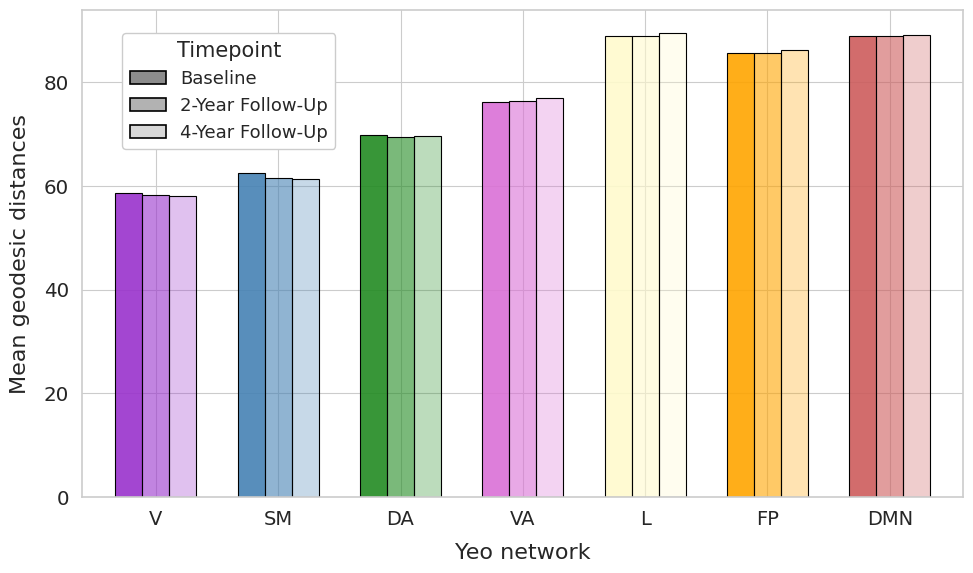

In [149]:
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

# --- 1. Define labels and palettes ---
yeo_labels = ["V", "SM", "DA", "VA", "L", "FP", "DMN"]

palette_labeled_networks = {
    'visual': 'darkorchid',
    'sensory motor': 'steelblue',
    'dorsal attention': 'forestgreen',
    'ventral attention': 'orchid',
    'limbic': 'lemonchiffon',
    'fronto parietal': 'orange',
    'DMN': 'indianred'
}

label_map = {
    "V": "visual",
    "SM": "sensory motor",
    "DA": "dorsal attention",
    "VA": "ventral attention",
    "L": "limbic",
    "FP": "fronto parietal",
    "DMN": "DMN"
}

palette_abbrev = {abbr: palette_labeled_networks[fullname] for abbr, fullname in label_map.items()}

# --- 2. Data ---

# Compute means per network
means_baseline = np.mean(yeo_mean_gd_baseline, axis=1)
means_fu2y = np.mean(yeo_mean_gd_fu2y, axis=1)
means_fu4y = np.mean(yeo_mean_gd_fu4y, axis=1)

# --- 3. Plot style ---
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["grid.linestyle"] = "-"
plt.rcParams["grid.linewidth"] = 0.8

fig, ax = plt.subplots(figsize=(10, 6))

# --- 4. Bar positions ---
n_networks = len(yeo_labels)
x = np.arange(n_networks)
bar_width = 0.22
offsets = np.array([-bar_width, 0, bar_width])

# alpha per timepoint
alpha_map = {"Baseline": 0.9, "2-Year Follow-Up": 0.6, "4-Year Follow-Up": 0.3}
timepoints = ["Baseline", "2-Year Follow-Up", "4-Year Follow-Up"]
all_data = [means_baseline, means_fu2y, means_fu4y]

# --- 5. Plot bars ---
for tp_idx, tp in enumerate(timepoints):
    for net_idx, net in enumerate(yeo_labels):
        color = palette_abbrev[net]
        ax.bar(
            x[net_idx] + offsets[tp_idx],
            all_data[tp_idx][net_idx],
            width=bar_width,
            color=mcolors.to_rgba(color, alpha=alpha_map[tp]),
            edgecolor="black",
            linewidth=0.8
        )

# --- 6. Axes, labels, and ticks ---
ax.set_xticks(x)
ax.set_xticklabels(yeo_labels, fontsize=14)
ax.set_xlabel("Yeo network", labelpad=10, fontsize=16)
ax.set_ylabel("Mean geodesic distances", labelpad=10, fontsize=16)

ax.set_xlim(-0.6, n_networks - 0.4)
ax.set_ylim(bottom=0)  # start y-axis at zero
#sns.despine(ax=ax)

# --- 7. Legend for timepoints (alpha-coded) ---
legend_patches = []
for tp in timepoints:
    rgba = mcolors.to_rgba("grey", alpha=alpha_map[tp])
    patch = Patch(facecolor=rgba, edgecolor="black", label=tp, linewidth=1.2)
    legend_patches.append(patch)

ax.legend(
    handles=legend_patches,
    title="Timepoint",
    bbox_to_anchor=(0.035, 0.97),
    loc="upper left",
    frameon=True,
    facecolor="white",
    framealpha=1,
    fontsize=13,
    title_fontsize=15
)

plt.tight_layout()

# plt.show()
plt.savefig(resdir_fig + "barplot_network_geodesic_distances.svg", format="svg", bbox_inches="tight", dpi=300)


## Variability in (individual-level) mean geodesic distances per network

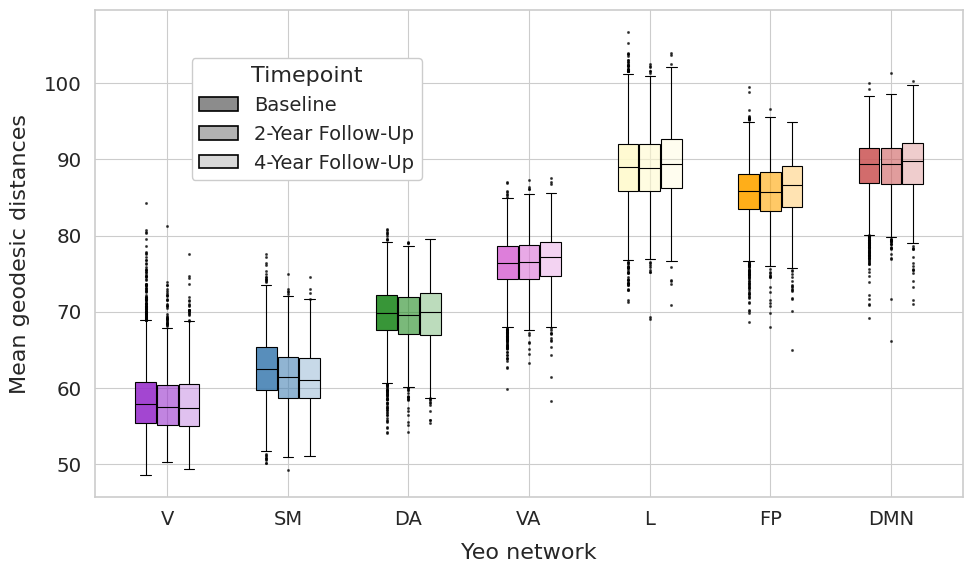

In [120]:
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

# --- Palettes and mapping ---

yeo_labels = ["V", "SM", "DA", "VA", "L", "FP", "DMN"]

palette_labeled_networks = {
    'visual': 'darkorchid',
    'sensory motor': 'steelblue',
    'dorsal attention': 'forestgreen',
    'ventral attention': 'orchid',
    'limbic': 'lemonchiffon',
    'fronto parietal': 'orange',
    'DMN': 'indianred'
}

label_map = {
    "V": "visual",
    "SM": "sensory motor",
    "DA": "dorsal attention",
    "VA": "ventral attention",
    "L": "limbic",
    "FP": "fronto parietal",
    "DMN": "DMN"
}

palette_abbrev = {abbr: palette_labeled_networks[fullname] for abbr, fullname in label_map.items()}

# --- Make tidy df (optional, but we'll extract values directly) ---
def colvals(arr):
    # arr: (n_networks, n_subjects)
    return [arr[i, :] for i in range(arr.shape[0])]

data_baseline = colvals(yeo_mean_gd_baseline)
data_fu2y     = colvals(yeo_mean_gd_fu2y)
data_fu4y     = colvals(yeo_mean_gd_fu4y)

# --- Plot style ---
sns.set_theme(style="whitegrid", font="DejaVu Sans", font_scale=1.3)
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["boxplot.medianprops.linewidth"] = 0.8
plt.rcParams["grid.linestyle"] = '-'
plt.rcParams["grid.linewidth"] = 0.8

fig, ax = plt.subplots(figsize=(10,6))

# --- Positioning ---
n_networks = len(yeo_labels)
network_pos = np.arange(n_networks)  # 0,1,2,...
box_width = 0.18   # width of each box
# offsets to produce three side-by-side boxes per network:
offsets = np.array([-box_width, 0.0, box_width])  # baseline, fu2y, fu4y

# alpha per timepoint
alpha_map = {"Baseline": 0.9, "2-Year Follow-Up": 0.6, "4-Year Follow-Up": 0.3}
timepoints = ["Baseline", "2-Year Follow-Up", "4-Year Follow-Up"]
all_data = [data_baseline, data_fu2y, data_fu4y]

# We will create a list of data in the order we will plot, and matching positions/colors/alphas
plot_data = []
positions = []
facecolors = []
edgecolors = []
alphas = []

for tp_idx, tp in enumerate(timepoints):
    arr = all_data[tp_idx]
    for net_idx in range(n_networks):
        plot_data.append(arr[net_idx])
        positions.append(network_pos[net_idx] + offsets[tp_idx])
        net_abbr = yeo_labels[net_idx]
        color = palette_abbrev[net_abbr]
        facecolors.append(color)
        edgecolors.append(color)
        alphas.append(alpha_map[tp])

# --- Draw boxplots with matplotlib, patch_artist=True to color boxes individually ---
bp = ax.boxplot(plot_data,
                positions=positions,
                widths=box_width * 0.95,
                patch_artist=True,
                manage_ticks=False,
                showfliers=True,
                boxprops=dict(linewidth=1.0),
                medianprops=dict(color='black', linewidth=1.5),
                whiskerprops=dict(color='black', linewidth=0.8),
                capprops=dict(color='black', linewidth=0.8),
                flierprops=dict(marker='o', markersize=1.2, alpha=0.6, markerfacecolor='black'))


# color each box individually (facecolor with alpha, opaque black edges)
for patch, fc, ec, a in zip(bp['boxes'], facecolors, edgecolors, alphas):
    rgba = mcolors.to_rgba(fc, alpha=a)   # apply alpha to facecolor only
    patch.set_facecolor(rgba)             # semi-transparent fill
    patch.set_edgecolor('black')          # always solid black border
    patch.set_linewidth(0.8)

# Also set whiskers/medians color to be slightly darker for visibility
for whisker in bp['whiskers']:
    whisker.set_color('black')
    whisker.set_linewidth(0.8)
for cap in bp['caps']:
    cap.set_color('black')
    cap.set_linewidth(0.8)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(0.8)


# --- X ticks: place at the network positions and label by abbreviation ---
ax.set_xticks(network_pos)
ax.set_xticklabels(yeo_labels, fontsize=14)

# Add small horizontal spacing so boxes don't touch
ax.set_xlim(-0.6, n_networks - 0.4)


# --- Create a legend for timepoint alpha (grey fill with constant black edge) ---
legend_patches = []
for tp in timepoints:
    rgba = mcolors.to_rgba('grey', alpha=alpha_map[tp])  # semi-transparent fill
    patch = Patch(facecolor=rgba, edgecolor='black', label=tp, linewidth=1.2)
    legend_patches.append(patch)

ax.legend(
    handles=legend_patches,
    title="Timepoint",
    bbox_to_anchor=(0.1, 0.92),
    loc="upper left",
    frameon=True,  # enable the frame
    facecolor='white',       # background color
    #edgecolor='grey',       # border color
    framealpha=1,          # opacity of the frame (1.0 = opaque)
    fontsize=14,
    title_fontsize=16
)


# Labels & polish
ax.set_xlabel("Yeo network", labelpad=10, fontsize=16)
ax.set_ylabel("Mean geodesic distances", labelpad=10, fontsize=16)

plt.tight_layout()

# plt.show()
plt.savefig(resdir_fig + "boxplot_network_geodesic_distances.svg", format="svg", bbox_inches="tight", dpi=300)
